# 005 — Evaluation

Step 1.5. How good is the model, measured in ways that survive 0.17% fraud?

- **PR-AUC** (average precision): one threshold-free number, read against its random baseline.
- **Threshold table**: precision, recall and alert volume at candidate thresholds.
- **Confusion matrix** at one threshold.

Everything here is measured on the **test set**, which neither the forest nor the calibrator has seen.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve

from src.config import settings
from src.ml.evaluate import bootstrap_pr_auc, confusion_at, summary_metrics, threshold_table
from src.ml.preprocess import load_splits
from src.ml.train import fit_risk_model

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

## 2. Train and score the test set

In [2]:
X_train, X_test, y_train, y_test = load_splits()
risk_model = fit_risk_model(X_train, y_train)
risk = risk_model.risk(X_test)
print(f"scored {len(risk):,} test rows ({y_test.sum()} fraud)")

scored 56,746 test rows (95 fraud)


## 3. Threshold-free summary

In [3]:
summary = summary_metrics(y_test, risk)
low, high = bootstrap_pr_auc(y_test, risk, n_resamples=1000, seed=settings.random_seed)

print(f"PR-AUC:          {summary['pr_auc']:.4f}   95% CI [{low:.4f}, {high:.4f}]")
print(f"random baseline: {summary['pr_auc_baseline']:.4f}   (the fraud rate)")
print(f"lift over random: {summary['pr_auc'] / summary['pr_auc_baseline']:.0f}x")
print(f"ROC-AUC:         {summary['roc_auc']:.4f}   (looks great, see the plot below)")

PR-AUC:          0.0850   95% CI [0.0605, 0.1237]
random baseline: 0.0017   (the fraud rate)
lift over random: 51x
ROC-AUC:         0.9376   (looks great, see the plot below)


## 4. PR curve vs ROC curve

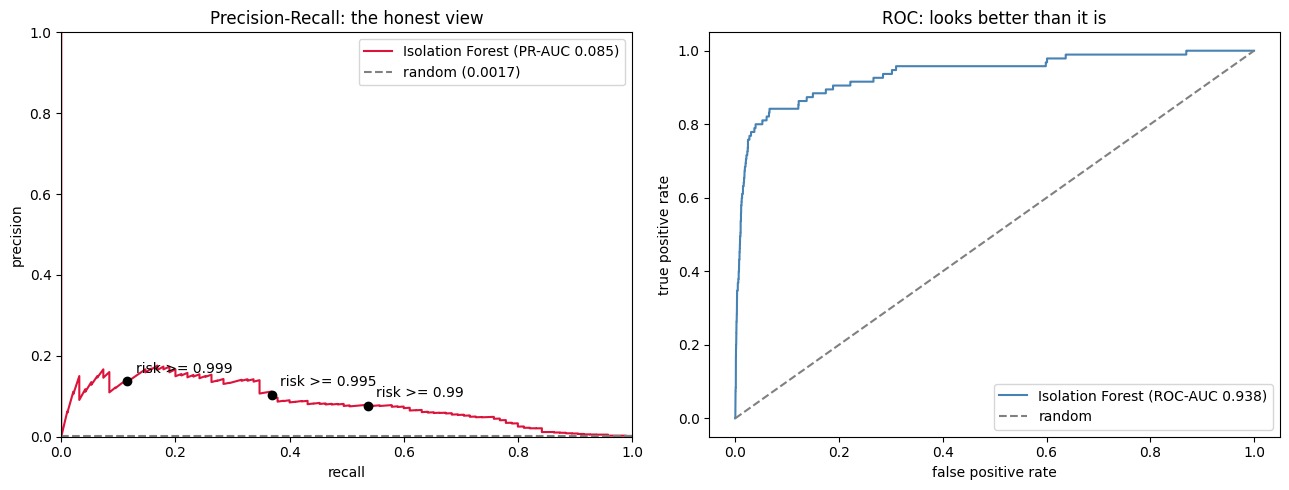

In [4]:
precision, recall, _ = precision_recall_curve(y_test, risk)
fpr, tpr, _ = roc_curve(y_test, risk)
marks = threshold_table(y_test, risk, thresholds=[0.99, 0.995, 0.999])

fig, (pr_ax, roc_ax) = plt.subplots(1, 2, figsize=(13, 5))

pr_ax.plot(recall, precision, color="crimson", label=f"Isolation Forest (PR-AUC {summary['pr_auc']:.3f})")
pr_ax.axhline(summary["pr_auc_baseline"], ls="--", color="gray", label=f"random ({summary['pr_auc_baseline']:.4f})")
for _, row in marks.iterrows():
    pr_ax.scatter(row["recall"], row["precision"], color="black", zorder=3)
    pr_ax.annotate(f"risk >= {row['threshold']}", (row["recall"], row["precision"]),
                   textcoords="offset points", xytext=(6, 6))
pr_ax.set(title="Precision-Recall: the honest view", xlabel="recall", ylabel="precision", xlim=(0, 1), ylim=(0, 1))
pr_ax.legend()

roc_ax.plot(fpr, tpr, color="steelblue", label=f"Isolation Forest (ROC-AUC {summary['roc_auc']:.3f})")
roc_ax.plot([0, 1], [0, 1], ls="--", color="gray", label="random")
roc_ax.set(title="ROC: looks better than it is", xlabel="false positive rate", ylabel="true positive rate")
roc_ax.legend()

plt.tight_layout()
plt.show()

## 5. Threshold table

In [5]:
table = threshold_table(y_test, risk, amounts=X_test["Amount"])
table

,threshold,flagged,flagged_%,tp,fp,fn,precision,recall,f1,normal_flagged_%,alerts_per_fraud,fraud_amount_caught_%
0,0.9000,5757,10.1452,80,5677,15,0.0139,0.8421,0.0273,10.0210,71.9625,84.8834
1,0.9500,2922,5.1493,76,2846,19,0.0260,0.8000,0.0504,5.0237,38.4474,72.7667
2,0.9800,1250,2.2028,67,1183,28,0.0536,0.7053,0.0996,2.0882,18.6567,71.9591
3,0.9900,661,1.1648,51,610,44,0.0772,0.5368,0.1349,1.0768,12.9608,52.5746
4,0.9950,337,0.5939,35,302,60,0.1039,0.3684,0.1620,0.5331,9.6286,31.9395
5,0.9980,144,0.2538,22,122,73,0.1528,0.2316,0.1841,0.2154,6.5455,23.9330
6,0.9990,80,0.1410,11,69,84,0.1375,0.1158,0.1257,0.1218,7.2727,4.3078


In [6]:
for threshold in [0.99, 0.995, 0.999]:
    row = table.set_index("threshold").loc[threshold]
    print(
        f"risk >= {threshold}: {row['recall']:.0%} recall, {row['precision']:.1%} precision, "
        f"{row['flagged_%']:.2f}% of transactions flagged, "
        f"{row['alerts_per_fraud']:.0f} alerts per fraud caught, "
        f"{row['fraud_amount_caught_%']:.0f}% of fraud money caught"
    )

risk >= 0.99: 54% recall, 7.7% precision, 1.16% of transactions flagged, 13 alerts per fraud caught, 53% of fraud money caught
risk >= 0.995: 37% recall, 10.4% precision, 0.59% of transactions flagged, 10 alerts per fraud caught, 32% of fraud money caught
risk >= 0.999: 12% recall, 13.8% precision, 0.14% of transactions flagged, 7 alerts per fraud caught, 4% of fraud money caught


## 6. Confusion matrix at one threshold

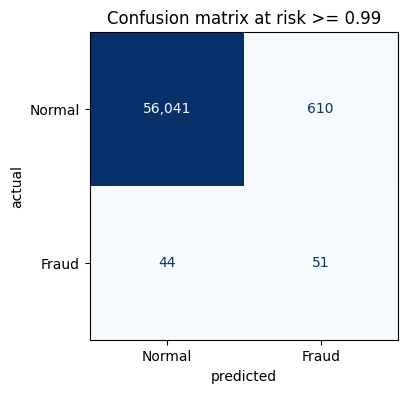

{'tp': 51, 'fp': 610, 'fn': 44, 'tn': 56041}

In [7]:
THRESHOLD = 0.99
counts = confusion_at(y_test, risk, THRESHOLD)
matrix = np.array([[counts["tn"], counts["fp"]], [counts["fn"], counts["tp"]]])

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matrix, display_labels=["Normal", "Fraud"]).plot(
    ax=ax, cmap="Blues", values_format=",d", colorbar=False
)
ax.set(title=f"Confusion matrix at risk >= {THRESHOLD}", xlabel="predicted", ylabel="actual")
plt.show()
counts

## 7. Same metrics on the training data

Step 1.6 must choose thresholds **without looking at the test set**. The 378 training fraud cases were never shown to the forest, so the training set can act as validation data. Check here that it tells the same story as the test set.

In [8]:
train_risk = risk_model.risk(X_train)
train_summary = summary_metrics(y_train, train_risk)

print(pd.DataFrame({"train": train_summary, "test": summary}).T[["n", "n_fraud", "pr_auc", "pr_auc_baseline", "roc_auc"]])

side_by_side = pd.concat(
    {
        "train": threshold_table(y_train, train_risk, thresholds=[0.99, 0.995, 0.999]).set_index("threshold"),
        "test": table.set_index("threshold").loc[[0.99, 0.995, 0.999]],
    },
    axis=1,
)
side_by_side.loc[:, (slice(None), ["recall", "precision", "normal_flagged_%"])]

                n  n_fraud  pr_auc  pr_auc_baseline  roc_auc
train 226980.0000 378.0000  0.1090           0.0017   0.9491
test   56746.0000  95.0000  0.0850           0.0017   0.9376


,train,test,train,test,train,test
,recall,recall,precision,precision,normal_flagged_%,normal_flagged_%
threshold,,,,,,
0.9900,0.5556,0.5368,0.0848,0.0772,1.0000,1.0768
0.9950,0.3862,0.3684,0.1142,0.1039,0.5000,0.5331
0.9990,0.1772,0.1158,0.2287,0.1375,0.0997,0.1218


## Step 1.5 findings

**Headline**
- **PR-AUC 0.085** (95% CI 0.061 to 0.124) against a random baseline of 0.0017: **51x better than random**.
- In absolute terms that is modest (a perfect model scores 1.0). It comes from an unsupervised model that never used a fraud label. Step 1.7 compares it with supervised XGBoost, which does.
- The interval is wide because the test set has only 95 fraud cases. Differences smaller than about 0.03 between models are not meaningful here.

**ROC-AUC 0.938 looks excellent, and it misleads.** Its false positive rate divides by 56,651 normal rows, so 610 false alarms is just 1.08% and barely visible on the ROC curve. In practice that is 610 false alarms for 51 real catches: 7.7% precision.

**Threshold table (test set)**

| risk >= | flagged | recall | precision | alerts per fraud | fraud money caught |
|---|---|---|---|---|---|
| 0.98 | 2.20% | 71% | 5.4% | 19 | 72% |
| 0.99 | 1.16% | **54%** | **7.7%** | 13 | 53% |
| 0.995 | 0.59% | 37% | 10.4% | 10 | 32% |
| 0.998 | 0.25% | 23% | 15.3% | 7 | 24% |
| 0.999 | 0.14% | 12% | 13.8% | 7 | 4% |

- **The trade-off is steep.** Each stricter threshold roughly halves the alert volume and gives up a large share of recall.
- **Precision never passes about 15%.** Even at the strictest thresholds, most alerts are false alarms.
- **Money falls faster than cases at the top.** At 0.999 the model catches 12% of fraud cases but only 4% of fraud money: the most anomalous-looking fraud is small. The large fraud sits at moderate risk.
- The precision dip from 0.998 to 0.999 (15.3% to 13.8%) rests on 22 and 11 catches. That is noise, not a real effect.

**Confusion matrix at risk >= 0.99:** 51 fraud caught, 44 missed, 610 false alarms, 56,041 correctly passed.

**Training data as validation (for Step 1.6)**
- PR-AUC is 0.109 on training data vs 0.085 on test. The training value falls inside the test confidence interval.
- Recall agrees closely: 55.6% vs 53.7% at 0.99, and 38.6% vs 36.8% at 0.995.
- Training precision runs slightly high. The training normals are the calibration reference, so they flag exactly 1.000% at 0.99, against 1.077% on test.
- **So Step 1.6 picks thresholds on training data, confirms them once on test, and expects test precision to come out a little lower.**